In [3]:
import pandas as pd                          # for data tables
import numpy as np                           # for numbers
import matplotlib.pyplot as plt              # for drawing graphs
import seaborn as sns                        # for beautiful graphs

from sklearn.datasets import load_breast_cancer          # our dataset
from sklearn.model_selection import train_test_split     # split data
from sklearn.tree import DecisionTreeClassifier, plot_tree  # our model
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score,
                             recall_score, f1_score)



In [15]:
# Load data
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)



In [10]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [13]:
print(df.columns.tolist())
print(df.head(2))

['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38           122.8     1001.0          0.11840   
1        20.57         17.77           132.9     1326.0          0.08474   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869          

In [ ]:
# Create dataframe
#  df['diagnosis] = data.target` → adds a column:
df = pd.DataFrame(data.data, columns=data.feature_names)
df['diagnosis'] = data.target   # 0 = Malignant(cancer), 1 = Benign(notcancer)

print(" Done! Shape:", df.shape)
print("Malignant (0):", sum(df['diagnosis'] == 0))
print("Benign    (1):", sum(df['diagnosis'] == 1))
df.head()

 Done! Shape: (569, 31)
Malignant (0): 212
Benign    (1): 357


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


##   Check the Data

> Before doing anything, we check:
> - How many patients total?
> - Any missing values? (empty cells in the table)
> - What are the column names?
>
> `isnull().sum().sum()` → counts empty/missing values
> If it says **0** → data is clean, no missing values 

In [20]:
print("Total patients :", len(df))
print("Missing values :", df.isnull().sum().sum())
print("\nColumn names:")
print(df.columns.tolist())

Total patients : 569
Missing values : 0

Column names:
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension', 'diagnosis']


## Bar Chart (Count Graph)

> A simple bar chart showing:
> - How many patients are Malignant?
> - How many are Benign?
>
> `value_counts()` → counts how many 0s and 1s
> `plot(kind='bar')` → draws a bar chart
> If one bar is much taller → dataset is imbalanced (more of one type)

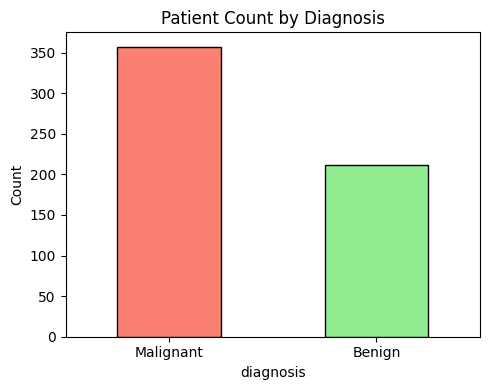

In [ ]:
# Graph 1: Count of each type
plt.figure(figsize=(5, 4)) #5 = width (horizontal) → 5 inches wide #4 = height (vertical) → 4 inches tall
df['diagnosis'].value_counts().plot(kind='bar', color=['salmon', 'lightgreen'], edgecolor='black')
plt.xticks([0, 1], ['Malignant', 'Benign'], rotation=0) #xticks means labels on the X-axis (bottom of graph).
plt.title('Patient Count by Diagnosis')
plt.ylabel('Count')
plt.tight_layout()  # fix spacing so nothing is cut off
plt.show()

 bins=25, divide data into 25 groups
alpha=0.6, 60% transparent so both colors visible

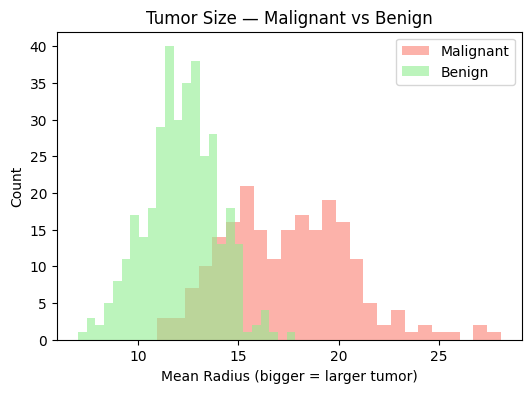

In [22]:
# Graph 2: Tumor size comparison
plt.figure(figsize=(6, 4))
for label, color, name in [(0,'salmon','Malignant'), (1,'lightgreen','Benign')]:
    plt.hist(df[df['diagnosis']==label]['mean radius'],
             bins=25, alpha=0.6, color=color, label=name)
plt.title('Tumor Size — Malignant vs Benign')
plt.xlabel('Mean Radius (bigger = larger tumor)')
plt.ylabel('Count')
plt.legend()
plt.show()

Read=go up to together, blue=opposite, white=no relation

df[mean_cols]  → table with only those 10 mean columns

 annot=True,show numbers inside each box
fmt='.2f',show only 2 decimal places (eg: 0.99)

plt.xticks(rotation=45), tilt x-axis labels 45 degrees (table type maa result display garne)

 ha='right', align text to right so it doesn't overlap

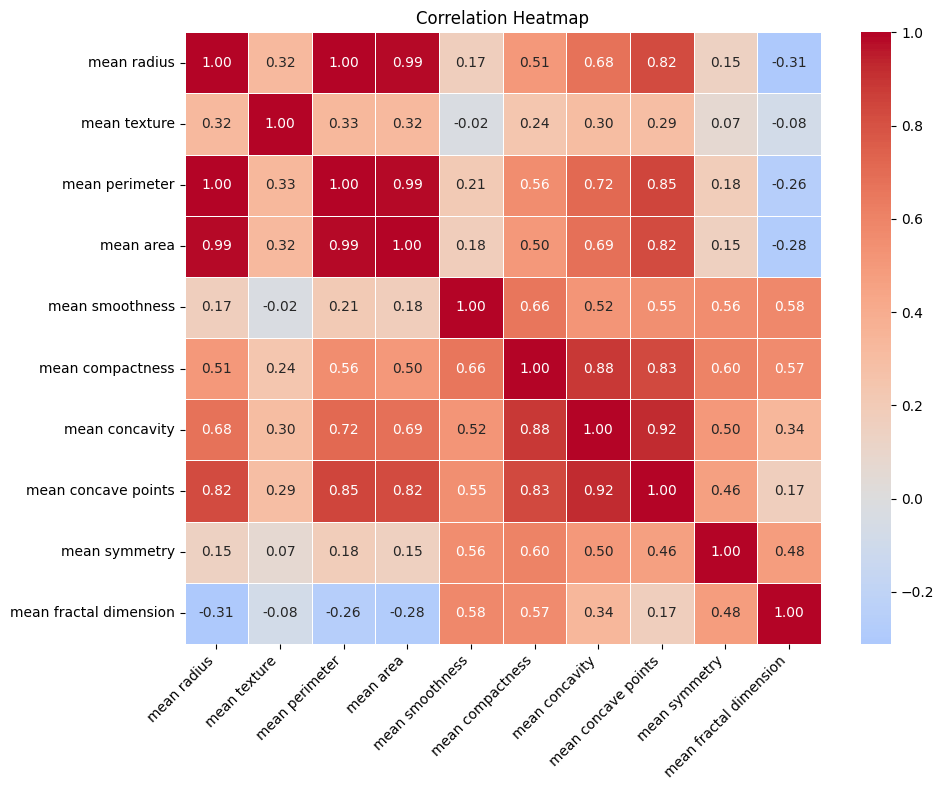

In [ ]:
mean_cols = [c for c in data.feature_names if 'mean' in c]
corr = df[mean_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [36]:


# Step 1 — define X with only important features FIRST
X = df[['worst concave points', 'worst perimeter', 'mean concave points']]
y = df['diagnosis']

# Step 2 — THEN split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% for testing, 80% for training
    random_state=42,     # same split every time you run
    stratify=y           # keep same ratio of 0s and 1s in both sets
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 455
Testing samples : 114


In [37]:
 # tree can ask maximum 4 questions deep, max_depth=4
model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)

print(" Model trained!")

 Model trained!


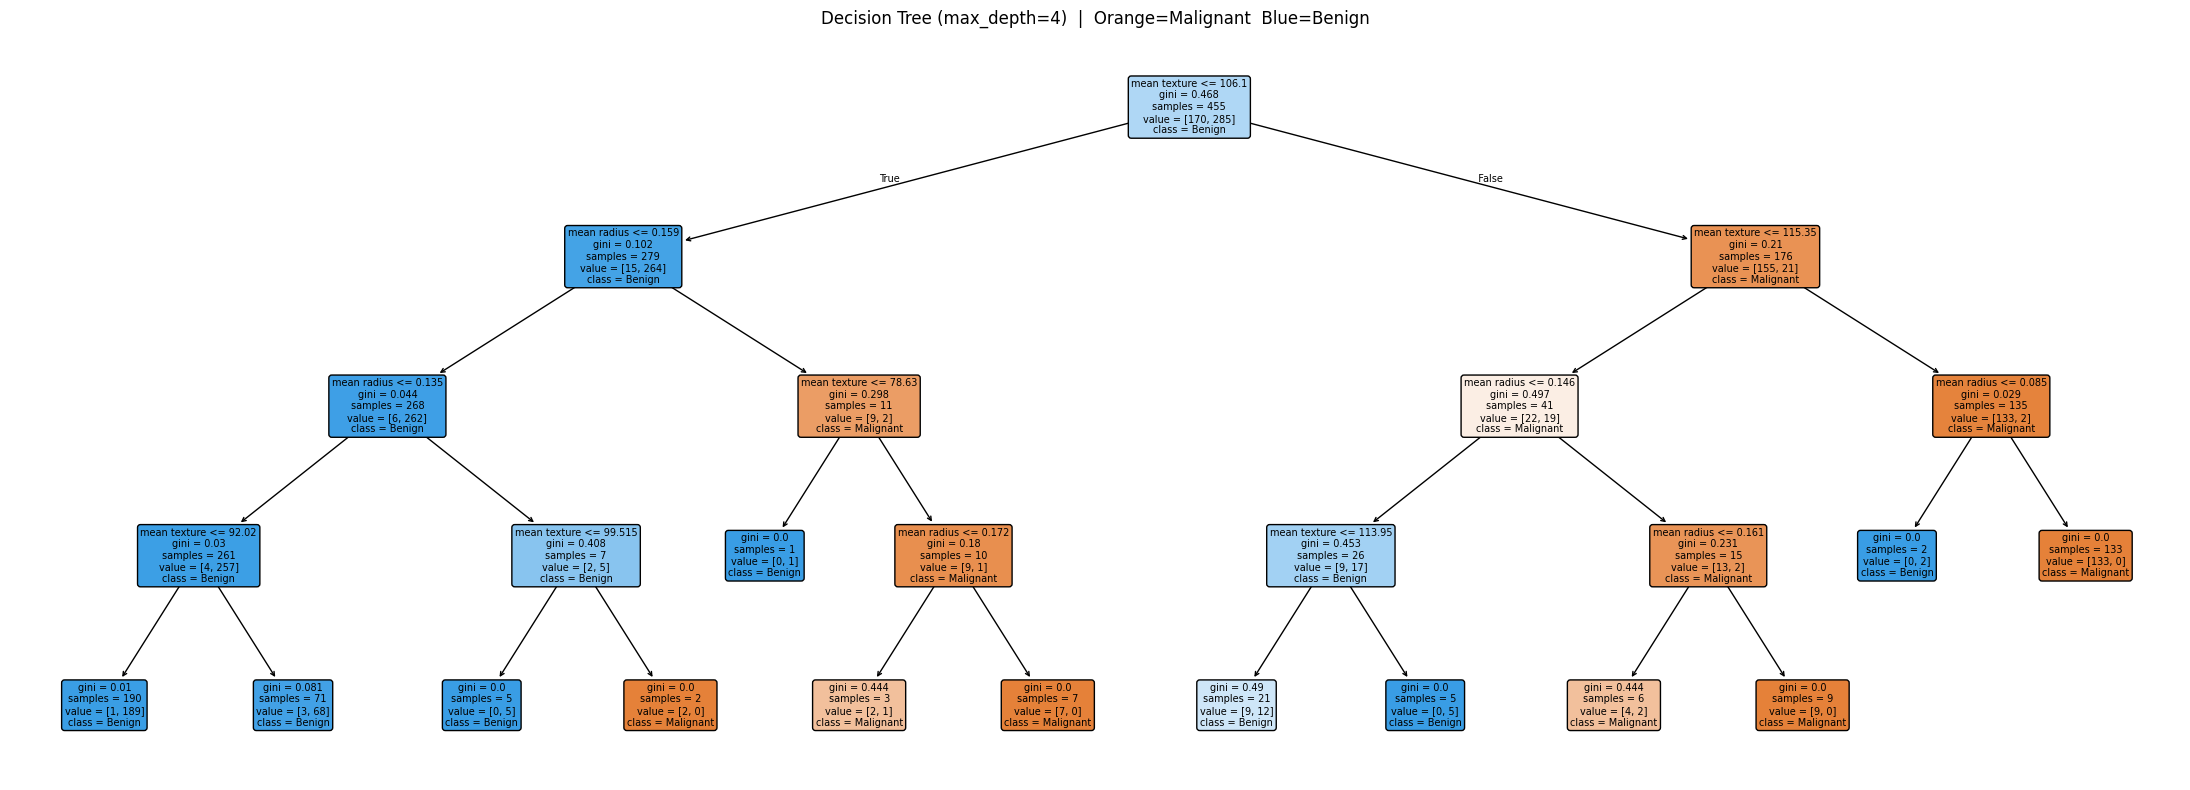

In [38]:
plt.figure(figsize=(22, 8))
plot_tree(model,
          feature_names=data.feature_names,
          class_names=['Malignant', 'Benign'],
          filled=True, rounded=True, fontsize=7)
plt.title('Decision Tree (max_depth=4)  |  Orange=Malignant  Blue=Benign')
plt.tight_layout()
plt.show()

In [46]:
y_pred = model.predict(X_test)
# predict 0 or 1 for all 114 test patients

result = pd.DataFrame({
    # create a table

    'Actual'   : ['Benign' if v==1 else 'Malignant' for v in y_test[:10]],
    # real answers of first 10 patients

    'Predicted': ['Benign' if v==1 else 'Malignant' for v in y_pred[:10]],
    # model's answers of first 10 patients
})

result['Correct?'] = result['Actual'] == result['Predicted']
# True if model was right, False if wrong

print(result.to_string(index=False))
# print table without row numbers

   Actual Predicted  Correct?
Malignant Malignant      True
   Benign    Benign      True
Malignant Malignant      True
   Benign Malignant     False
Malignant Malignant      True
   Benign    Benign      True
   Benign    Benign      True
Malignant Malignant      True
Malignant Malignant      True
Malignant Malignant      True


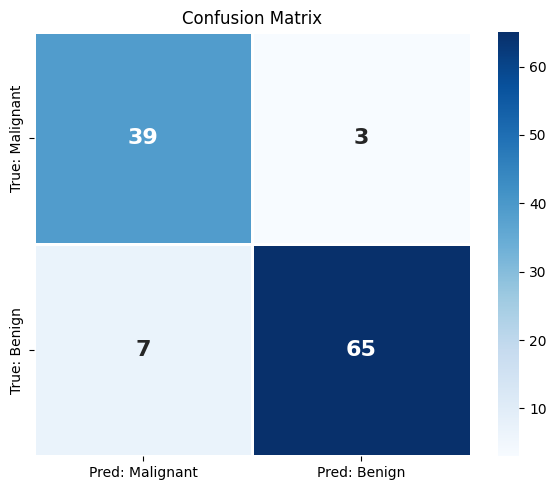

TN = 39  correctly caught Malignant
FP = 3  said Benign but was Malignant  ← DANGEROUS
FN = 7  said Malignant but was Benign
TP = 65  correctly caught Benign


In [ ]:
cm = confusion_matrix(y_test, y_pred)
# compare real answers vs model answers
# gives a 2x2 table of counts

tn, fp, fn, tp = cm.ravel()
plt.figure(figsize=(6, 5))         # create graph width=6 height=5
sns.heatmap(cm,                    # draw heatmap using confusion matrix
            annot=True,            # show numbers inside boxes
            fmt='d',               # show as whole numbers (not 39.0, just 39)
            cmap='Blues',          # color scheme — light to dark blue
            xticklabels=['Pred: Malignant', 'Pred: Benign'],  # x-axis labels
            yticklabels=['True: Malignant', 'True: Benign'],  # y-axis labels
            linewidths=1,          # thin lines between boxes
            annot_kws={"size": 16, "weight": "bold"})  # numbers big and bold

plt.title('Confusion Matrix')      # graph heading
plt.tight_layout()                 # fix spacing
plt.show()                         # display graph

print(f"TN = {tn}  correctly caught Malignant")
print(f"FP = {fp}  said Benign but was Malignant  ← DANGEROUS")
print(f"FN = {fn}  said Malignant but was Benign")
print(f"TP = {tp}  correctly caught Benign")
# f"..." → inserts variable value directly into text
# eg: f"TN = {tn}" → prints "TN = 39"

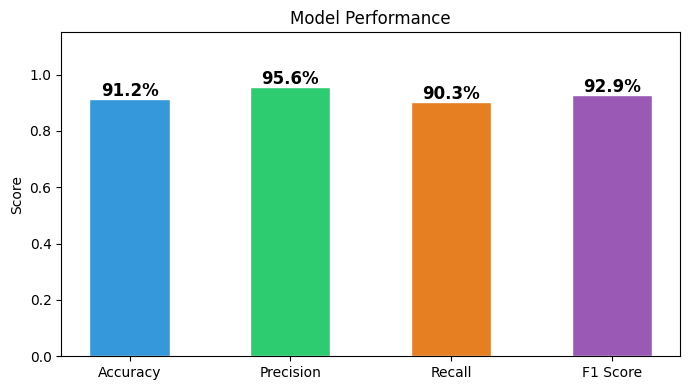

Accuracy  : 91.2%
Precision : 95.6%
Recall    : 90.3%
F1 Score  : 92.9%


In [49]:
acc  = accuracy_score(y_test, y_pred)   # how many correct out of all patients
prec = precision_score(y_test, y_pred)  # when said Benign, how often right?
rec  = recall_score(y_test, y_pred)     # of all real Benign, how many found?
f1   = f1_score(y_test, y_pred)         # balance of precision and recall

plt.figure(figsize=(7, 4))              # create graph width=7 height=4
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']  # bar names
values  = [acc, prec, rec, f1]          # bar heights
colors  = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6']     # color of each bar

bars = plt.bar(metrics, values,         # draw bar chart
               color=colors,            # apply colors
               edgecolor='white',       # white border on each bar
               width=0.5)               # bar width

for bar, val in zip(bars, values):
# loop through each bar and its value together
# zip() → pairs each bar with its value
# eg: (accuracy bar, 0.94), (precision bar, 0.96)...

    plt.text(bar.get_x() + bar.get_width()/2,
    # get_x()          → left edge of bar
    # + bar.get_width()/2  → move to center of bar

             bar.get_height() + 0.01,
             # place text just above the bar

             f"{val*100:.1f}%",
             # val*100    → convert 0.94 to 94
             # :.1f       → show 1 decimal place
             # eg: 94.0%

             ha='center',           # center the text horizontally
             fontsize=12,           # text size
             fontweight='bold')     # make text bold

plt.ylim(0, 1.15)           # y-axis goes from 0 to 1.15 (extra space for text)
plt.title('Model Performance')      # graph heading
plt.ylabel('Score')                 # y-axis label
plt.tight_layout()                  # fix spacing
plt.show()                          # display graph

print(f"Accuracy  : {acc*100:.1f}%")   # eg: Accuracy  : 94.0%
print(f"Precision : {prec*100:.1f}%")  # eg: Precision : 96.0%
print(f"Recall    : {rec*100:.1f}%")   # eg: Recall    : 94.0%
print(f"F1 Score  : {f1*100:.1f}%")    # eg: F1 Score  : 95.0%

macro avg    → use when both classes are equally important
weighted avg → use when one class has more patients than other

In [42]:
print(classification_report(y_test, y_pred, target_names=['Malignant','Benign']))

              precision    recall  f1-score   support

   Malignant       0.85      0.93      0.89        42
      Benign       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114



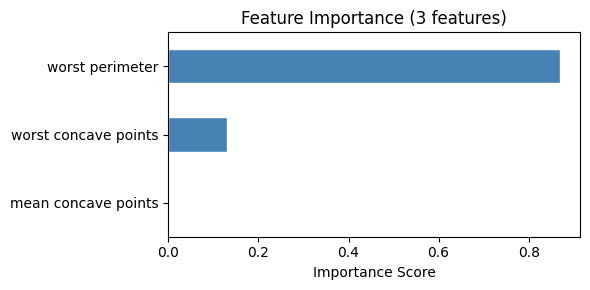

Feature importance:
  worst perimeter: 0.870
  worst concave points: 0.130
  mean concave points: 0.000


In [45]:
# feature importance — which of the 3 features mattered most
importances = pd.Series(model.feature_importances_,
                        index=X.columns)        # use X.columns not data.feature_names
top3 = importances.sort_values()

plt.figure(figsize=(6, 3))
top3.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Feature Importance (3 features)')    # graph heading
plt.xlabel('Importance Score')                  # x-axis label
plt.tight_layout()                              # fix spacing
plt.show()

print("Feature importance:")
for name, val in importances.sort_values(ascending=False).items():
    print(f"  {name}: {val:.3f}")